In [2]:
# Exécution locale (remplace l'upload Google Colab)
# Assurez-vous que le fichier lab_pred.csv est dans le même dossier que ce notebook
import os
print("Répertoire courant :", os.getcwd())

ModuleNotFoundError: No module named 'google.colab'

In [8]:
import pandas as pd
# Charger ton dataset
df = pd.read_csv("lab_pred.csv")

In [9]:
df

,labid,labname,result_time,validation_time,turnaround_time_mins,gender,age,unittype,admissionweight,recent_diagnosis,lab_workload_last_hour
0,44971395,potassium,-5070,-5027,43,Female,> 89,Med-Surg ICU,48.1,NaN,31
1,44971397,alkaline phos.,-5070,-5027,43,Female,> 89,Med-Surg ICU,48.1,NaN,31
2,51000461,Hgb,-5070,-5048,22,Female,> 89,Med-Surg ICU,48.1,NaN,31
3,44971404,calcium,-5070,-5027,43,Female,> 89,Med-Surg ICU,48.1,NaN,31
4,44971402,bicarbonate,-5070,-5027,43,Female,> 89,Med-Surg ICU,48.1,NaN,31
...,...,...,...,...,...,...,...,...,...,...,...
427940,823740639,calcium,27999,28047,48,Male,73,SICU,75.0,renal|disorder of kidney|chronic renal insuffi...,9
427941,823740634,chloride,27999,28047,48,Male,73,SICU,75.0,renal|disorder of kidney|chronic renal insuffi...,9
427942,823740640,anion gap,27999,28047,48,Male,73,SICU,75.0,renal|disorder of kidney|chronic renal insuffi...,9
427943,823740636,BUN,27999,28047,48,Male,73,SICU,75.0,renal|disorder of kidney|chronic renal insuffi...,9


In [10]:
import pandas as pd
from datetime import datetime, timedelta

# Charger ton dataset
df = pd.read_csv("lab_pred.csv")

# Fixer une date de référence (par exemple arbitraire : 2026-05-01 00:00:00)
reference_date = datetime(2026, 5, 1, 0, 0, 0)

# Conversion des colonnes en vraies dates
df["result_time"] = df["result_time"].apply(lambda x: reference_date + timedelta(minutes=x))
df["validation_time"] = df["validation_time"].apply(lambda x: reference_date + timedelta(minutes=x))

# Sauvegarder si besoin
df.to_csv("dataset_converti.csv", index=False)

df.head()



,labid,labname,result_time,validation_time,turnaround_time_mins,gender,age,unittype,admissionweight,recent_diagnosis,lab_workload_last_hour
0,44971395,potassium,2026-04-27 11:30:00,2026-04-27 12:13:00,43,Female,> 89,Med-Surg ICU,48.1,NaN,31
1,44971397,alkaline phos.,2026-04-27 11:30:00,2026-04-27 12:13:00,43,Female,> 89,Med-Surg ICU,48.1,NaN,31
2,51000461,Hgb,2026-04-27 11:30:00,2026-04-27 11:52:00,22,Female,> 89,Med-Surg ICU,48.1,NaN,31
3,44971404,calcium,2026-04-27 11:30:00,2026-04-27 12:13:00,43,Female,> 89,Med-Surg ICU,48.1,NaN,31
4,44971402,bicarbonate,2026-04-27 11:30:00,2026-04-27 12:13:00,43,Female,> 89,Med-Surg ICU,48.1,NaN,31


In [11]:
# Extraire les 5 valeurs maximales
top5 = df["turnaround_time_mins"].nlargest(5)

print(top5)

42237    93546
42238    93546
42239    93546
42240    93546
42241    93546
Name: turnaround_time_mins, dtype: int64


In [12]:
print(len(df))

427945


In [13]:
# Boucle sur la colonne gender
nb_femmes=0
nb_hommes=0
for g in df["gender"]:
    if g == "Female":
        nb_femmes += 1
    elif g == "Male":
        nb_hommes += 1

print("Nombre de Femmes :", nb_femmes)
print("Nombre de Hommes :", nb_hommes)



Nombre de Femmes : 162305
Nombre de Hommes : 265560


In [14]:
non = 0
for i in df["recent_diagnosis"]:
    if pd.isnull(i):   # Vérifie si la valeur est NaN
        non += 1

print("Nombre de valeurs manquantes dans recent_diagnosis :", non)

Nombre de valeurs manquantes dans recent_diagnosis : 131405


In [16]:

valeur_frequente = df["recent_diagnosis"].mode()[0]
nb_occurrences = df["recent_diagnosis"].value_counts().iloc[0]

print("Valeur la plus fréquente :", valeur_frequente)
print("Nombre d'occurrences :", nb_occurrences)

Valeur la plus fréquente : pulmonary|respiratory failure|acute respiratory failure
Nombre d'occurrences : 11649


In [20]:
# 2️⃣ Mettre en minuscule les colonnes textuelles (exemple : recent_diagnosis, labname)
df["recent_diagnosis"] = df["recent_diagnosis"].str.lower()
df["labname"] = df["labname"].str.lower()

# 3️⃣ Supprimer les espaces inutiles au début/fin
df["recent_diagnosis"] = df["recent_diagnosis"].str.strip()
df["labname"] = df["labname"].str.strip()

# 4️⃣ Remplacer les valeurs manquantes par "unknown" dans recent_diagnosis
df["recent_diagnosis"].fillna("unknown", inplace=True)

# 5️⃣ Vérification rapide
print("Nombre de lignes :", len(df))
print("Valeurs uniques dans recent_diagnosis :", df["recent_diagnosis"].nunique())
df.head()

Nombre de lignes : 427945
Valeurs uniques dans recent_diagnosis : 705


/tmp/ipykernel_280582/1049216412.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["recent_diagnosis"].fillna("unknown", inplace=True)


,labid,labname,result_time,validation_time,turnaround_time_mins,gender,age,unittype,admissionweight,recent_diagnosis,lab_workload_last_hour
0,44971395,potassium,2026-04-27 11:30:00,2026-04-27 12:13:00,43,Female,> 89,Med-Surg ICU,48.1,unknown,31
1,44971397,alkaline phos.,2026-04-27 11:30:00,2026-04-27 12:13:00,43,Female,> 89,Med-Surg ICU,48.1,unknown,31
2,51000461,hgb,2026-04-27 11:30:00,2026-04-27 11:52:00,22,Female,> 89,Med-Surg ICU,48.1,unknown,31
3,44971404,calcium,2026-04-27 11:30:00,2026-04-27 12:13:00,43,Female,> 89,Med-Surg ICU,48.1,unknown,31
4,44971402,bicarbonate,2026-04-27 11:30:00,2026-04-27 12:13:00,43,Female,> 89,Med-Surg ICU,48.1,unknown,31


In [21]:
# Calculer les corrélations avec la target
correlations = df.corr(numeric_only=True)["turnaround_time_mins"].sort_values(ascending=False)

print(correlations)

turnaround_time_mins      1.000000
admissionweight          -0.003125
lab_workload_last_hour   -0.004385
labid                    -0.017395
Name: turnaround_time_mins, dtype: float64


In [23]:
df.columns


Index(['labid', 'labname', 'result_time', 'validation_time',
       'turnaround_time_mins', 'gender', 'age', 'unittype', 'admissionweight',
       'recent_diagnosis', 'lab_workload_last_hour'],
      dtype='object')

In [24]:
df["result_year"] = df["result_time"].dt.year
df["result_month"] = df["result_time"].dt.month
df["result_day"] = df["result_time"].dt.day
df["result_hour"] = df["result_time"].dt.hour
df["result_weekday"] = df["result_time"].dt.weekday

# Ensuite tu supprimes la colonne brute datetime
df = df.drop(columns=["result_time", "validation_time"])


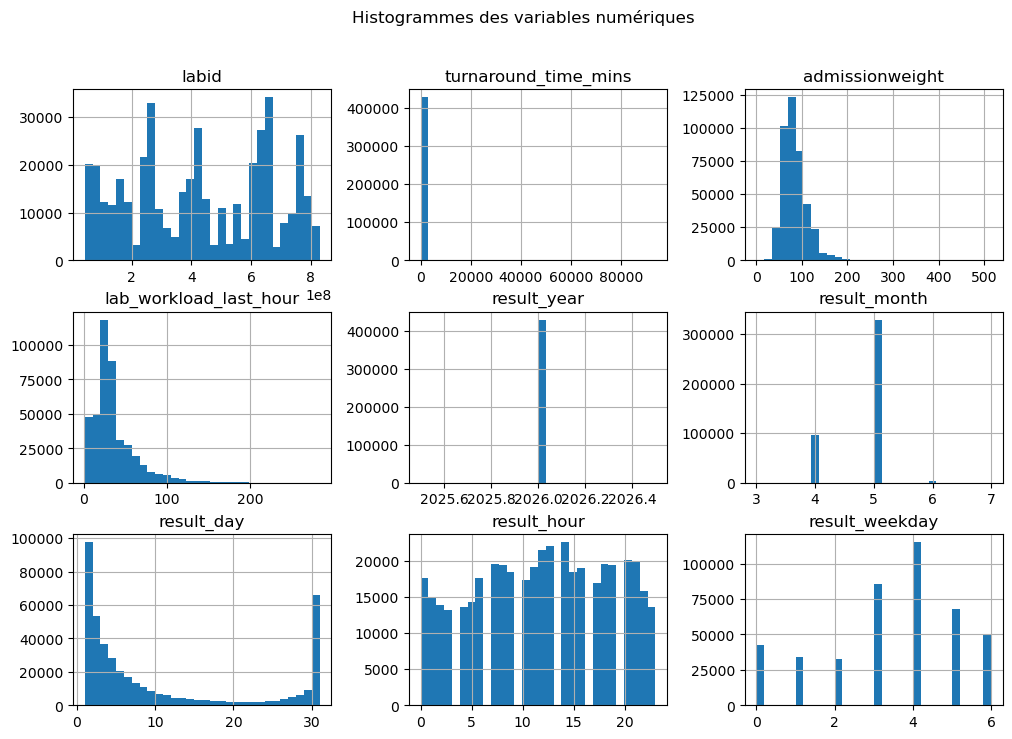

In [25]:
import matplotlib.pyplot as plt
# Histogrammes pour les variables numériques
df.hist(figsize=(12, 8), bins=30)
plt.suptitle("Histogrammes des variables numériques")
plt.show()

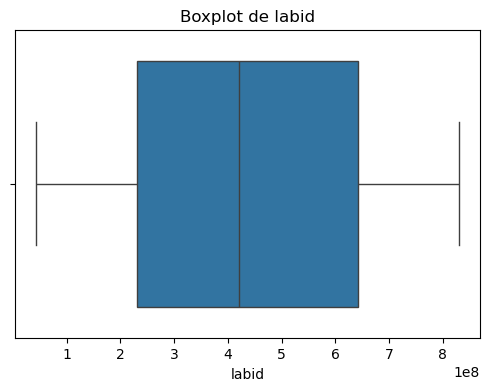

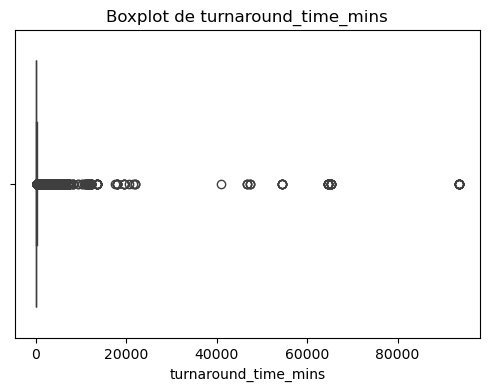

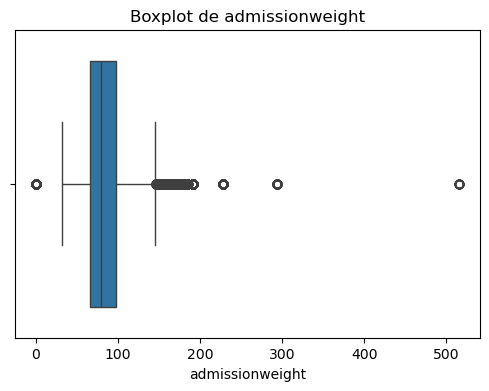

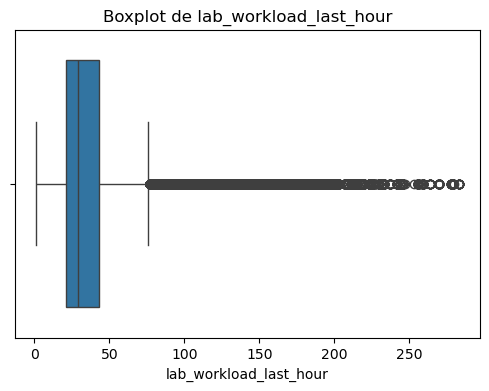

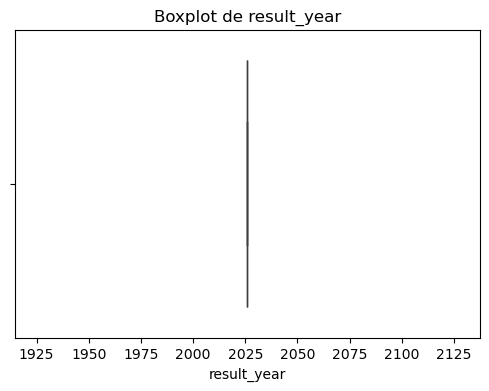

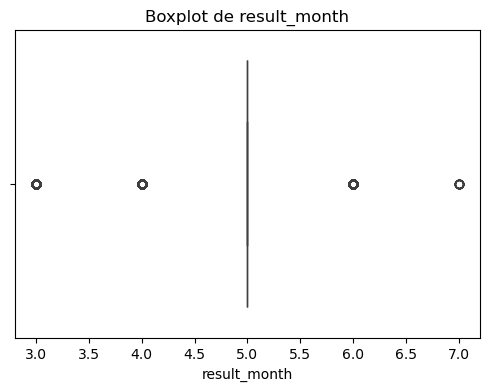

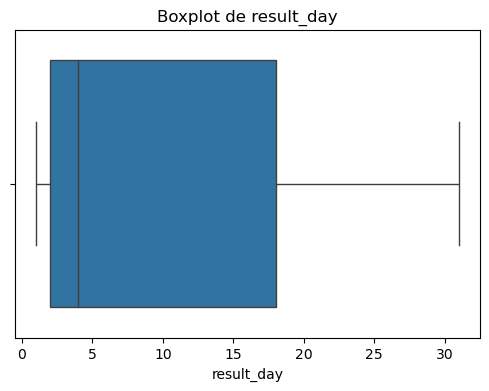

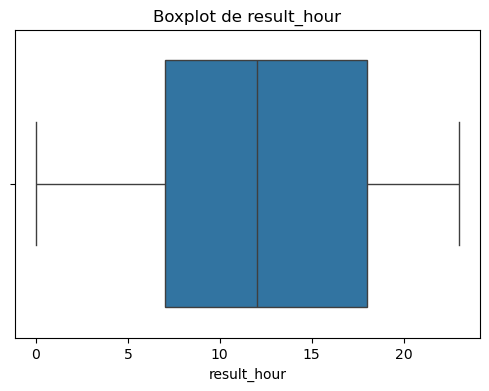

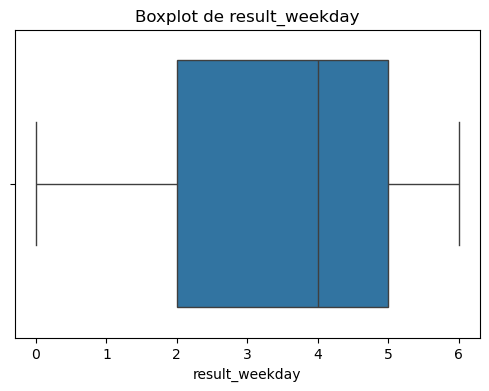

In [27]:
import seaborn as sns
# Boxplots pour détecter les outliers
for col in df.select_dtypes(include="number").columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

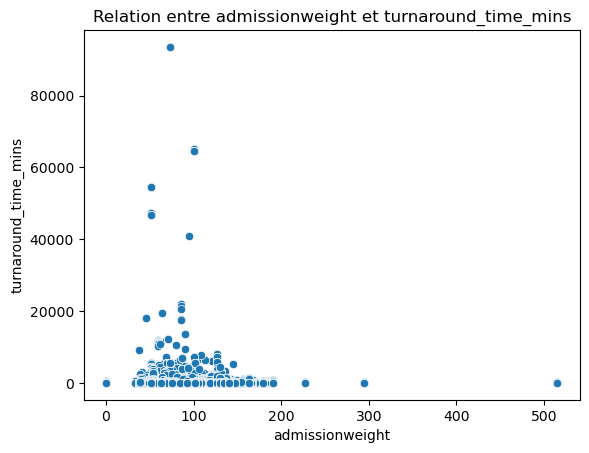

In [28]:
# Scatter plots pour deux variables numériques
sns.scatterplot(x="admissionweight", y="turnaround_time_mins", data=df)
plt.title("Relation entre admissionweight et turnaround_time_mins")
plt.show()

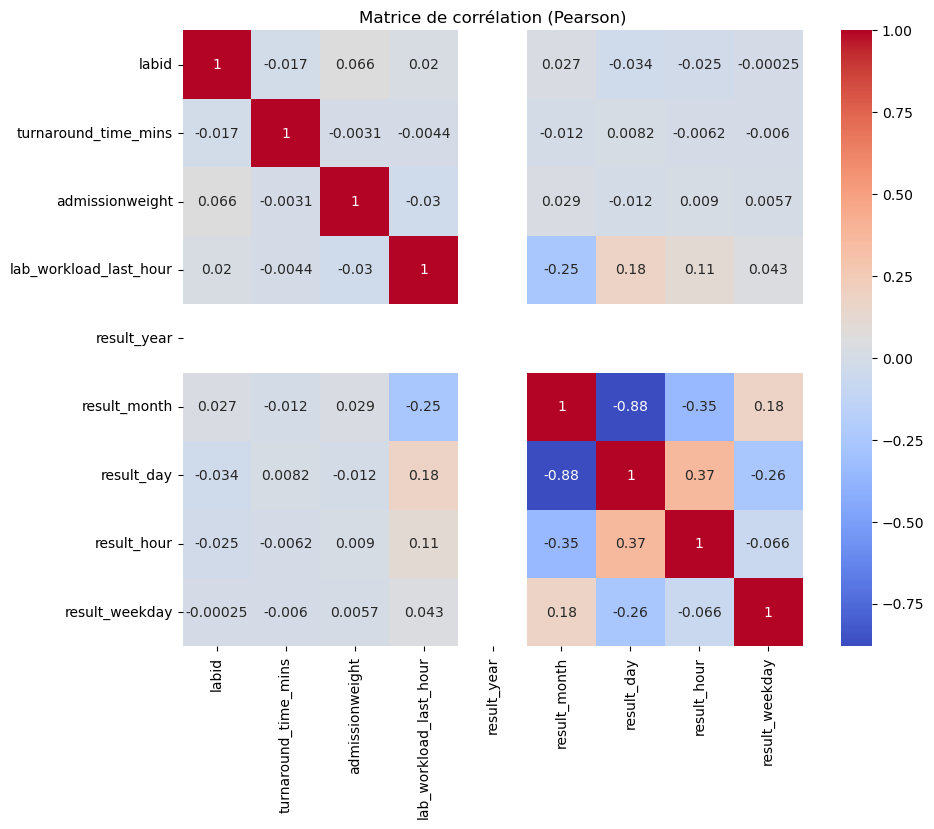

In [29]:
# Corrélations (Pearson)
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation (Pearson)")
plt.show()

In [30]:
# Cross-tabulation pour deux variables catégorielles
print(pd.crosstab(df["labname"], df["unittype"]))

unittype                      CCU-CTICU  CSICU  CTICU  Cardiac ICU  MICU  \
labname                                                                    
-bands                               18      4      5           27   119   
-basos                              256    136     89          482   488   
-eos                                259    130     93          489   509   
-lymphs                             256    147     94          527   555   
-monos                              257    147     94          526   548   
...                                 ...    ...    ...          ...   ...   
wbc's in cerebrospinal fluid          0      0      0            2     1   
wbc's in peritoneal fluid             0      0      0            0     0   
wbc's in pleural fluid                0      0      0            0     0   
wbc's in synovial fluid               0      0      0            0     0   
wbc's in urine                       11      3     12           30     6   

unittype   

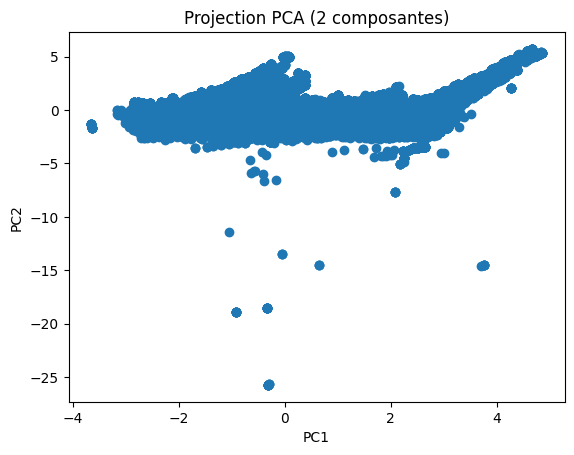

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# PCA (réduction de dimensionnalité)
X_num = df.select_dtypes(include="number").dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("Projection PCA (2 composantes)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
# Gestion des valeurs manquantes
df = df.fillna("Unknown")  # pour les catégorielles
df = df.fillna(df.mean(numeric_only=True))  # pour les numériques

# Encodage des variables catégorielles
df_encoded = pd.get_dummies(df, drop_first=True)

# Normalisation des variables numériques
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded.select_dtypes(include="number"))

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Encodage des variables catégorielles
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=["turnaround_time_mins"])
y = df_encoded["turnaround_time_mins"]

# Random Forest
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# Importance des features
importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).head(20))


admissionweight_73.3                                                              0.385155
age_Unknown                                                                       0.216843
recent_diagnosis_cardiovascular|ventricular disorders|congestive heart failure    0.073134
labid                                                                             0.060025
lab_workload_last_hour                                                            0.038304
result_hour                                                                       0.023394
result_day                                                                        0.022127
labname_fio2                                                                      0.020302
recent_diagnosis_neurologic|seizures|seizures|status epilepticus                  0.018233
labname_total co2                                                                 0.016552
result_weekday                                                                    0.013700

In [ ]:
!pip install tensorflow

In [ ]:
print(df_encoded.columns.tolist())


['labid', 'turnaround_time_mins', 'lab_workload_last_hour', 'result_year', 'result_month', 'result_day', 'result_hour', 'result_weekday', 'labname_-basos', 'labname_-eos', 'labname_-lymphs', 'labname_-monos', 'labname_-polys', 'labname_24 h urine protein', 'labname_24 h urine urea nitrogen', 'labname_acetaminophen', 'labname_albumin', 'labname_alkaline phos.', 'labname_alt (sgpt)', 'labname_amikacin - peak', 'labname_amikacin - trough', 'labname_ammonia', 'labname_amylase', 'labname_anf/ana', 'labname_anion gap', 'labname_ast (sgot)', 'labname_base deficit', 'labname_base excess', 'labname_bedside glucose', 'labname_bicarbonate', 'labname_bnp', 'labname_bun', 'labname_calcium', 'labname_carbamazepine', 'labname_carboxyhemoglobin', 'labname_cd 4', 'labname_chloride', 'labname_clostridium difficile toxin a+b', 'labname_cortisol', 'labname_cpk', 'labname_cpk-mb', 'labname_cpk-mb index', 'labname_creatinine', 'labname_crp', 'labname_crp-hs', 'labname_device', 'labname_digoxin', 'labname_di

In [ ]:
important_features = [
    "admissionweight_73.3",
    "age_Unknown",
    "recent_diagnosis_cardiovascular|ventricular disorders|congestive heart failure",
    "labid",
    "lab_workload_last_hour",
    "result_hour",
    "result_day",
    "labname_fio2",
    "recent_diagnosis_neurologic|seizures|seizures|status epilepticus",
    "labname_total co2",
    "result_weekday",
    "labname_temperature"
]
for f in important_features:
    if f not in df_encoded.columns:
        print("Manquant :", f,"\n")
    else:
      print("exixte", f)


exixte admissionweight_73.3
exixte age_Unknown
exixte recent_diagnosis_cardiovascular|ventricular disorders|congestive heart failure
exixte labid
exixte lab_workload_last_hour
exixte result_hour
exixte result_day
exixte labname_fio2
exixte recent_diagnosis_neurologic|seizures|seizures|status epilepticus
exixte labname_total co2
exixte result_weekday
exixte labname_temperature


In [ ]:
# === 1. Imports ===
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


# === 3. Définir les features explicatives ===
important_features = [
    "admissionweight_73.3",
    "age_Unknown",
    "recent_diagnosis_cardiovascular|ventricular disorders|congestive heart failure",
    "labid",
    "lab_workload_last_hour",
    "result_hour",
    "result_day",
    "labname_fio2",
    "recent_diagnosis_neurologic|seizures|seizures|status epilepticus",
    "labname_total co2",
    "result_weekday",
    "labname_temperature"
]

X = df_encoded[important_features]   # ✅ plus d’erreur
y = df_encoded["turnaround_time_mins"]

# === 4. Split train/test (80/20) ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === 5. Normalisation ===
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# === 6. Définition du MLP ===
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping pour éviter l’overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=100, batch_size=32,
                    validation_data=(X_test, y_test),

                    callbacks=[early_stop])

# Prédictions sur le jeu de test
y_pred = model.predict(X_test)
# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R²
r2 = r2_score(y_test, y_pred)
loss, mae = model.evaluate(X_test, y_test)
print(f"MAE amélioré sur test : {mae:.4f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² : {r2:.4f}")


# === 9. Sauvegarde du modèle ===
model.save("/content/mlp_model_final.keras")   # format natif recommandé

# === 10. Téléchargement du modèle ===
files.download("/content/mlp_model_final.keras")

# === 11. Sauvegarde et téléchargement du CSV modifié ===
df.to_csv("/content/movies_updated_vrai_modified.csv", index=False)
files.download("/content/movies_updated_vrai_modified.csv")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - loss: 449725.0000 - mae: 62.8243 - val_loss: 254906.8281 - val_mae: 55.4924
Epoch 2/100
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 258455.2344 - mae: 59.2605 - val_loss: 243068.5000 - val_mae: 58.6151
Epoch 3/100
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 226297.2188 - mae: 58.5114 - val_loss: 247209.0000 - val_mae: 56.0911
Epoch 4/100
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 272673.1250 - mae: 59.0335 - val_loss: 240524.5312 - val_mae: 57.4420
Epoch 5/100
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 213163.5938 - mae: 58.0978 - val_loss: 243979.8125 - val_mae: 57.3587
Epoch 6/100
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 237142.8906 - mae: 58.4179 - val_loss: 225133.1250 - val_mae: 56.7055
Epoch 7/100
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 231338.6406 - mae: 58.4739 - val_loss: 229501.1719 - val_mae: 57.7798
Epoch 8/100
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 32s

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

2675/2675 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


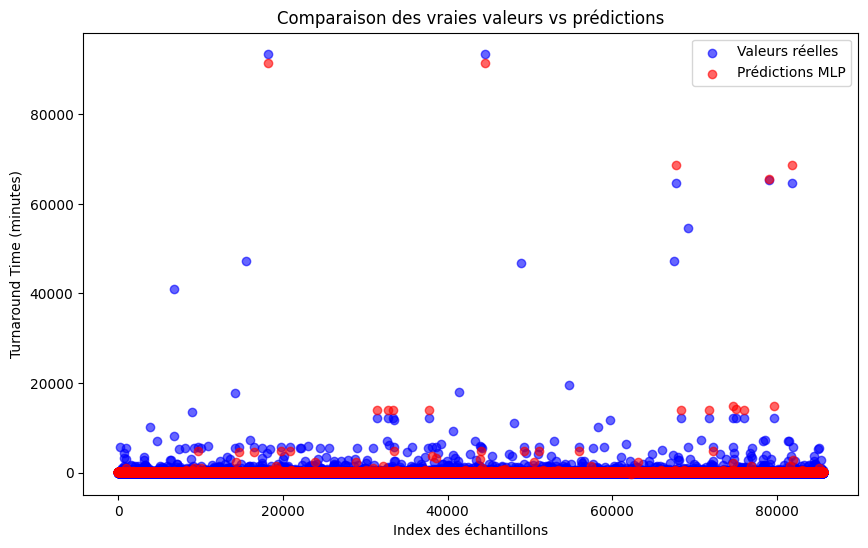

In [ ]:
import matplotlib.pyplot as plt

# Prédictions
y_pred = model.predict(X_test)

# Graphique comparatif
plt.figure(figsize=(10,6))
plt.scatter(range(len(y_test)), y_test, label="Valeurs réelles", color="blue", alpha=0.6)
plt.scatter(range(len(y_pred)), y_pred, label="Prédictions MLP", color="red", alpha=0.6)

plt.title("Comparaison des vraies valeurs vs prédictions")
plt.xlabel("Index des échantillons")
plt.ylabel("Turnaround Time (minutes)")
plt.legend()
plt.show()


2675/2675 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


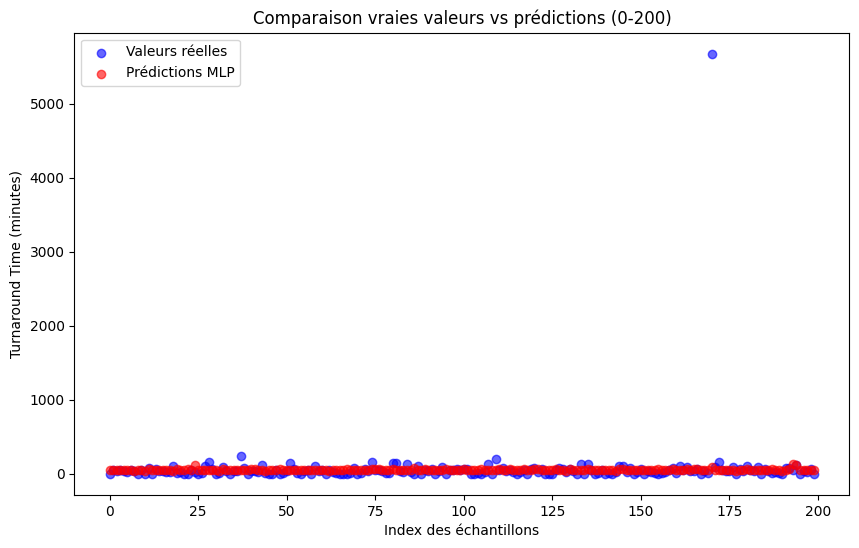

In [ ]:
import matplotlib.pyplot as plt

# Prédictions
y_pred = model.predict(X_test)

# Limiter aux 200 premiers échantillons
sample_size = 200
y_test_sample = y_test[:sample_size]
y_pred_sample = y_pred[:sample_size]

# Graphique comparatif
plt.figure(figsize=(10,6))
plt.scatter(range(len(y_test_sample)), y_test_sample, label="Valeurs réelles", color="blue", alpha=0.6)
plt.scatter(range(len(y_pred_sample)), y_pred_sample, label="Prédictions MLP", color="red", alpha=0.6)

plt.title("Comparaison vraies valeurs vs prédictions (0-200)")
plt.xlabel("Index des échantillons")
plt.ylabel("Turnaround Time (minutes)")
plt.legend()
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Entraînement du modèle
lr = LinearRegression()
lr.fit(X_train, y_train)

# Prédictions
y_pred_lr = lr.predict(X_test)

# Évaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Régression Linéaire - MAE : {mae_lr:.2f}")
print(f"Régression Linéaire - RMSE : {rmse_lr:.2f}")
print(f"Régression Linéaire - R² : {r2_lr:.4f}")


Régression Linéaire - MAE : 61.25
Régression Linéaire - RMSE : 501.24
Régression Linéaire - R² : 0.5547


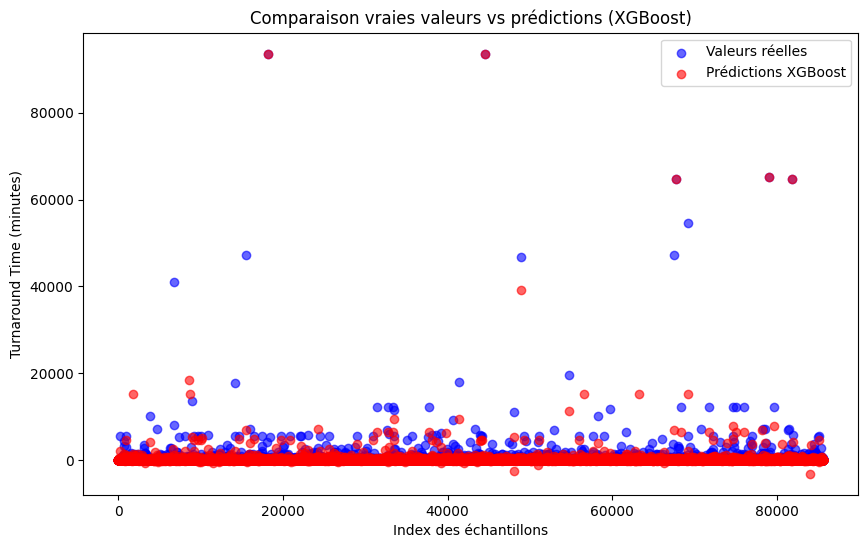

In [ ]:
import matplotlib.pyplot as plt

# Graphique comparatif (valeurs réelles vs prédictions)
plt.figure(figsize=(10,6))
plt.scatter(range(len(y_test)), y_test, label="Valeurs réelles", color="blue", alpha=0.6)
plt.scatter(range(len(y_pred_xgb)), y_pred_xgb, label="Prédictions XGBoost", color="red", alpha=0.6)

plt.title("Comparaison vraies valeurs vs prédictions (XGBoost)")
plt.xlabel("Index des échantillons")
plt.ylabel("Turnaround Time (minutes)")
plt.legend()
plt.show()


In [ ]:
import lightgbm as lgb

# Entraînement
lgbm = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=-1,
                         subsample=0.8, colsample_bytree=0.8, random_state=42)
lgbm.fit(X_train, y_train)

# Prédictions
y_pred_lgbm = lgbm.predict(X_test)

# Évaluation
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print(f"LightGBM - MAE : {mae_lgbm:.2f}")
print(f"LightGBM - RMSE : {rmse_lgbm:.2f}")
print(f"LightGBM - R² : {r2_lgbm:.4f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039415 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 565
[LightGBM] [Info] Number of data points in the train set: 342356, number of used features: 11
[LightGBM] [Info] Start training from score 64.559999


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM - MAE : 58.18
LightGBM - RMSE : 413.01
LightGBM - R² : 0.6976


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.1 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor

# Entraînement
cat = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                        random_seed=42, verbose=0)
cat.fit(X_train, y_train)

# Prédictions
y_pred_cat = cat.predict(X_test)

# Évaluation
mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2_cat = r2_score(y_test, y_pred_cat)

print(f"CatBoost - MAE : {mae_cat:.2f}")
print(f"CatBoost - RMSE : {rmse_cat:.2f}")
print(f"CatBoost - R² : {r2_cat:.4f}")


CatBoost - MAE : 54.17
CatBoost - RMSE : 395.77
CatBoost - R² : 0.7224


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ----------- MODELE LEAKY RELU -----------
model_leaky = Sequential([
    Dense(256, input_shape=(X_train.shape[1],)),
    LeakyReLU(alpha=0.01),
    Dropout(0.4),
    Dense(128),
    LeakyReLU(alpha=0.01),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1)
])

model_leaky.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Entraînement
history_leaky = model_leaky.fit(X_train, y_train, epochs=30, batch_size=32,
                                validation_data=(X_test, y_test), verbose=0)

# Évaluation
y_pred_leaky = model_leaky.predict(X_test)
mae_leaky = mean_absolute_error(y_test, y_pred_leaky)
rmse_leaky = np.sqrt(mean_squared_error(y_test, y_pred_leaky))
r2_leaky = r2_score(y_test, y_pred_leaky)

print(f"LeakyReLU - MAE : {mae_leaky:.2f}")
print(f"LeakyReLU - RMSE : {rmse_leaky:.2f}")
print(f"LeakyReLU - R² : {r2_leaky:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


2675/2675 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
LeakyReLU - MAE : 55.37
LeakyReLU - RMSE : 439.78
LeakyReLU - R² : 0.6572


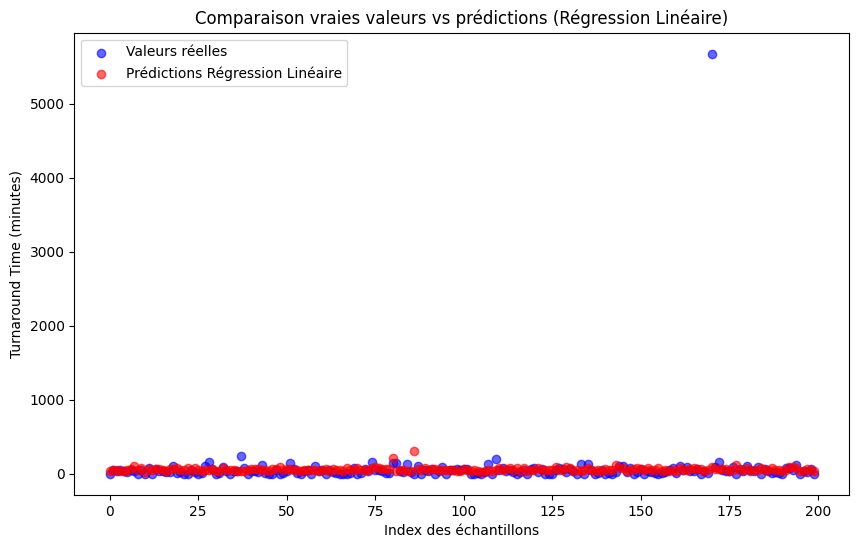

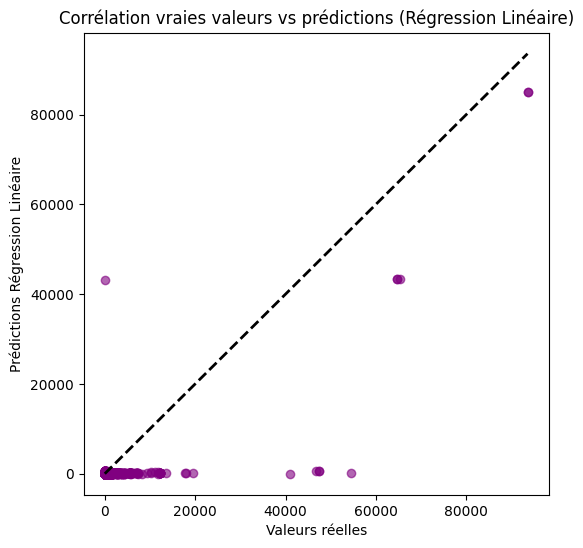

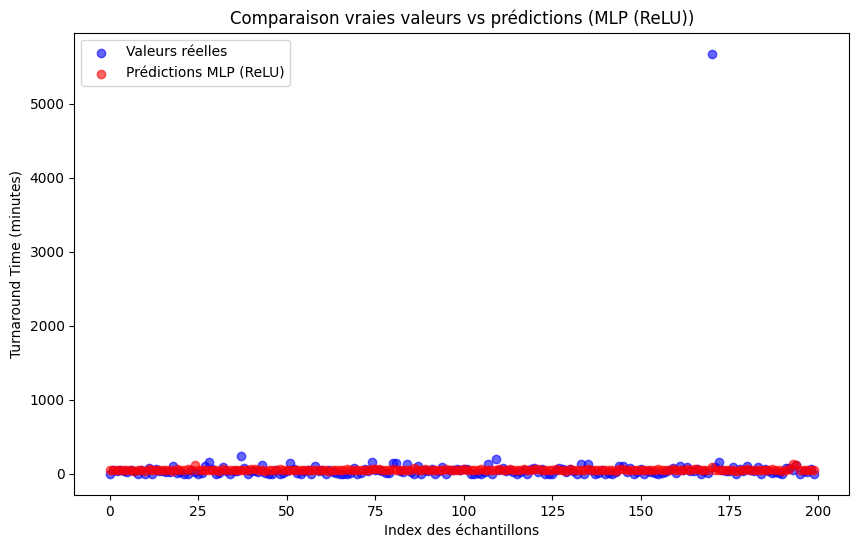

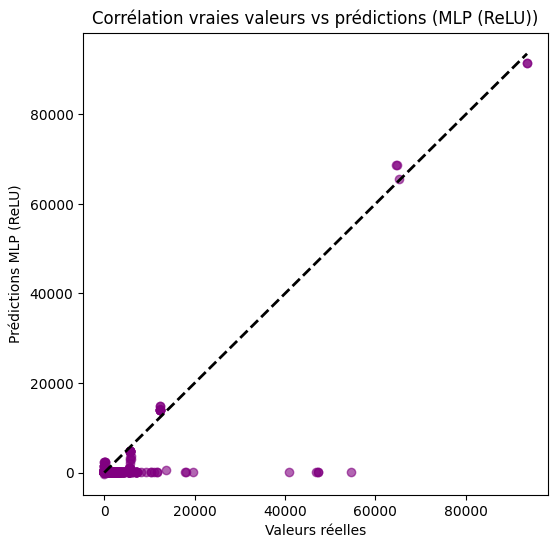

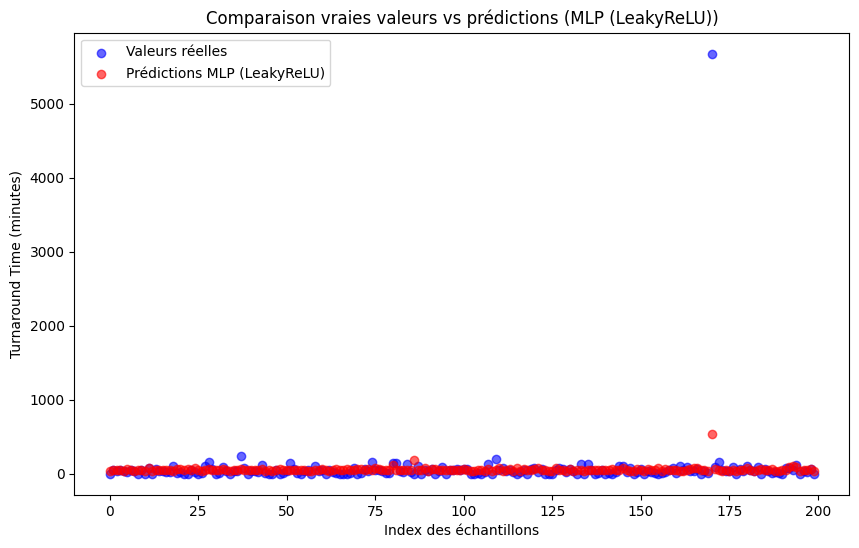

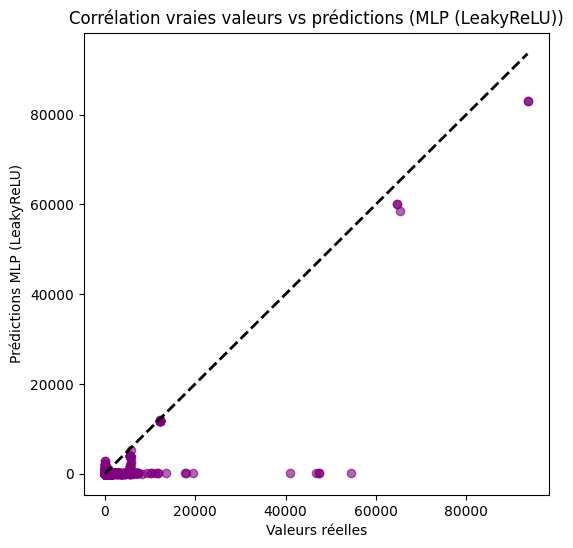

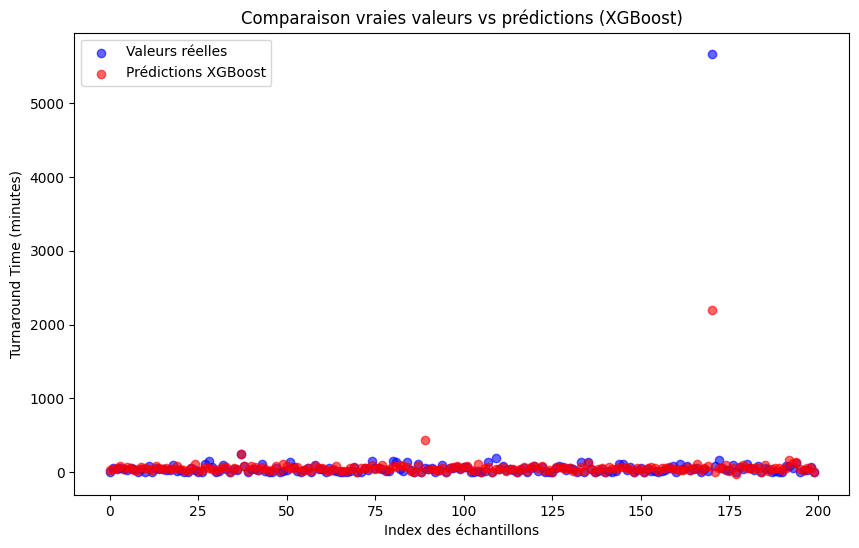

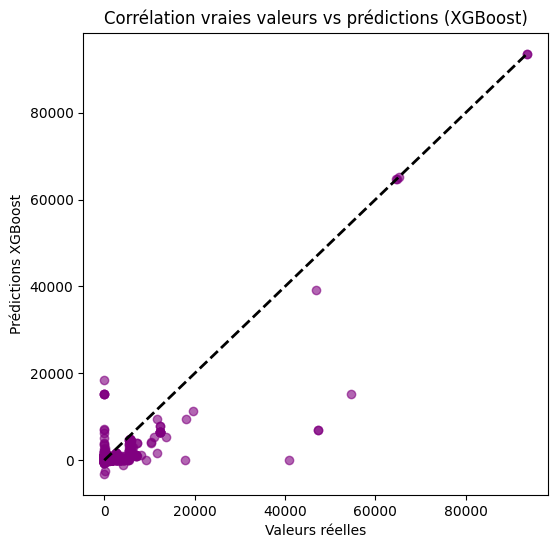

In [ ]:
import matplotlib.pyplot as plt

# Fonction utilitaire pour tracer un graphe comparatif
def plot_predictions(y_test, y_pred, model_name, limit=200):
    plt.figure(figsize=(10,6))
    plt.scatter(range(len(y_test[:limit])), y_test[:limit],
                label="Valeurs réelles", color="blue", alpha=0.6)
    plt.scatter(range(len(y_pred[:limit])), y_pred[:limit],
                label=f"Prédictions {model_name}", color="red", alpha=0.6)
    plt.title(f"Comparaison vraies valeurs vs prédictions ({model_name})")
    plt.xlabel("Index des échantillons")
    plt.ylabel("Turnaround Time (minutes)")
    plt.legend()
    plt.show()

    # Graphe de corrélation
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.6, color="purple")
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'k--', lw=2)  # ligne idéale
    plt.xlabel("Valeurs réelles")
    plt.ylabel(f"Prédictions {model_name}")
    plt.title(f"Corrélation vraies valeurs vs prédictions ({model_name})")
    plt.show()


# Exemple d’utilisation pour chaque modèle
plot_predictions(y_test, y_pred_lr, "Régression Linéaire")
plot_predictions(y_test, y_pred, "MLP (ReLU)")
plot_predictions(y_test, y_pred_leaky, "MLP (LeakyReLU)")
plot_predictions(y_test, y_pred_xgb, "XGBoost")


In [ ]:
print(df.columns)


Index(['labid', 'labname', 'turnaround_time_mins', 'gender', 'age', 'unittype',
       'admissionweight', 'recent_diagnosis', 'lab_workload_last_hour',
       'result_year', 'result_month', 'result_day', 'result_hour',
       'result_weekday'],
      dtype='object')


In [ ]:
def categorize_hour(hour):
    if 6 <= hour < 12:
        return "matin"
    elif 12 <= hour < 18:
        return "apres_midi"
    elif 18 <= hour < 24:
        return "soir"
    else:
        return "nuit"

df["time_category"] = df["result_hour"].apply(categorize_hour)

# Encodage en variables binaires (one-hot)
df = pd.get_dummies(df, columns=["time_category"], drop_first=True)


In [ ]:
def categorize_weekday(day):
    if day in [5, 6]:  # 5 = samedi, 6 = dimanche
        return "weekend"
    else:
        return "weekday"

df["day_category"] = df["result_weekday"].apply(categorize_weekday)

df = pd.get_dummies(df, columns=["day_category"], drop_first=True)


In [ ]:
def categorize_workload(w):
    if w < 10:
        return "faible"
    elif w < 30:
        return "moyen"
    else:
        return "eleve"

df["workload_category"] = df["lab_workload_last_hour"].apply(categorize_workload)

df = pd.get_dummies(df, columns=["workload_category"], drop_first=True)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2675/2675 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
LeakyReLU - MAE : 54.75
LeakyReLU - RMSE : 442.63
LeakyReLU - R² : 0.6527


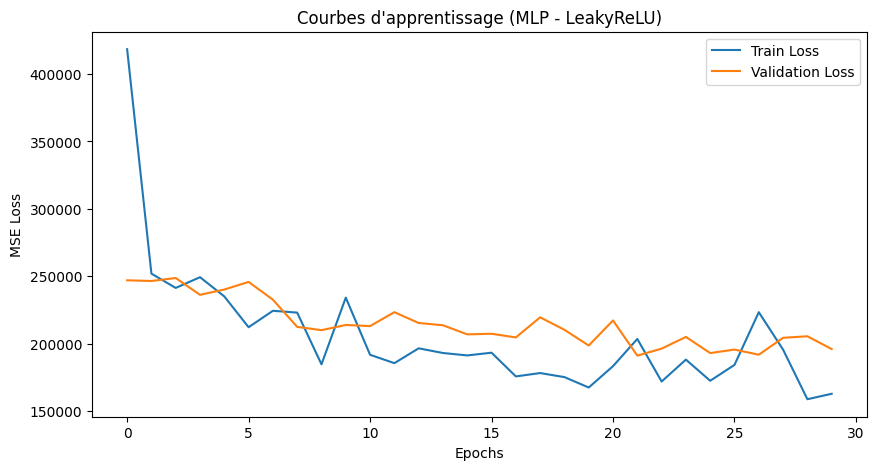

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# ----------- MODELE MLP (LeakyReLU) -----------
model_leaky = Sequential([
    Dense(256, input_shape=(X_train.shape[1],)),
    LeakyReLU(negative_slope=0.01),
    Dropout(0.4),
    Dense(128),
    LeakyReLU(negative_slope=0.01),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1)
])

model_leaky.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Entraînement
history_leaky = model_leaky.fit(X_train, y_train, epochs=30, batch_size=32,
                                validation_data=(X_test, y_test), verbose=0)

# Évaluation
y_pred_leaky = model_leaky.predict(X_test)
mae_leaky = mean_absolute_error(y_test, y_pred_leaky)
rmse_leaky = np.sqrt(mean_squared_error(y_test, y_pred_leaky))
r2_leaky = r2_score(y_test, y_pred_leaky)

print(f"LeakyReLU - MAE : {mae_leaky:.2f}")
print(f"LeakyReLU - RMSE : {rmse_leaky:.2f}")
print(f"LeakyReLU - R² : {r2_leaky:.4f}")

# Courbes d'apprentissage
plt.figure(figsize=(10,5))
plt.plot(history_leaky.history['loss'], label='Train Loss')
plt.plot(history_leaky.history['val_loss'], label='Validation Loss')
plt.title("Courbes d'apprentissage (MLP - LeakyReLU)")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


In [ ]:
# Estimer l'heure de sortie
df["estimated_validation_hour"] = (df["result_hour"]*60 + df["turnaround_time_mins"]) // 60
df["estimated_validation_hour"] = df["estimated_validation_hour"] % 24  # pour rester entre 0-23

# Catégoriser
def categorize_hour(hour):
    if 6 <= hour < 12:
        return "matin"
    elif 12 <= hour < 18:
        return "apres_midi"
    elif 18 <= hour < 24:
        return "soir"
    else:
        return "nuit"

df["turnaround_category"] = df["estimated_validation_hour"].apply(categorize_hour)


In [ ]:
import pandas as pd

# Construire la date/heure du test
df["result_datetime"] = pd.to_datetime(dict(
    year=df["result_year"],
    month=df["result_month"],
    day=df["result_day"],
    hour=df["result_hour"]
))

# Ajouter le délai pour obtenir la date/heure de sortie
df["estimated_validation_datetime"] = df["result_datetime"] + pd.to_timedelta(df["turnaround_time_mins"], unit="m")


In [ ]:
# Jour exact de sortie
df["validation_day"] = df["estimated_validation_datetime"].dt.strftime("%d-%m")

# Heure de sortie
df["validation_hour"] = df["estimated_validation_datetime"].dt.hour

# Catégoriser en matin / après-midi / soirée / nuit
def categorize_hour(hour):
    if 6 <= hour < 12:
        return "matin"
    elif 12 <= hour < 18:
        return "apres_midi"
    elif 18 <= hour < 24:
        return "soiree"
    else:
        return "nuit"

df["validation_category"] = df["validation_hour"].apply(categorize_hour)


In [ ]:
df["target_enriched"] = (
    df["validation_day"] + " - " +
    df["validation_category"]
)


In [ ]:
# Exemple : remplacer "> 89" par 90
df["age"] = df["age"].replace({"> 89": 90})

# Si certaines valeurs sont manquantes ou non numériques
df["age"] = pd.to_numeric(df["age"], errors="coerce")


In [ ]:
df["admissionweight"] = pd.to_numeric(df["admissionweight"], errors="coerce")


In [ ]:
df["age"].fillna(df["age"].median(), inplace=True)
df["admissionweight"].fillna(df["admissionweight"].median(), inplace=True)


/tmp/ipykernel_114356/1650233027.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)
/tmp/ipykernel_114356/1650233027.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models

# Features utilisées (les mêmes que dans tes modèles précédents)
X = df[["age", "admissionweight", "lab_workload_last_hour",
        "result_hour", "result_weekday"]]

# Target catégorielle (matin, apres_midi, soir, nuit)
y = df["turnaround_category"]

# Encodage de la target
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Normalisation des features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)


In [ ]:
num_classes = len(encoder.classes_)

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")  # classification multi-classes
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=30,
                    batch_size=32,
                    verbose=1)


Epoch 1/30
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - accuracy: 0.9120 - loss: 0.2977 - val_accuracy: 0.9419 - val_loss: 0.2103
Epoch 2/30
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9385 - loss: 0.2319 - val_accuracy: 0.9417 - val_loss: 0.2062
Epoch 3/30
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9393 - loss: 0.2292 - val_accuracy: 0.9419 - val_loss: 0.2052
Epoch 4/30
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.9394 - loss: 0.2272 - val_accuracy: 0.9408 - val_loss: 0.2040
Epoch 5/30
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.9395 - loss: 0.2259 - val_accuracy: 0.9419 - val_loss: 0.2043
Epoch 6/30
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - accuracy: 0.9398 - loss: 0.2237 - val_accuracy: 0.9419 - val_loss: 0.2034
Epoch 7/30
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.9399 - loss: 0.2228 - val_accuracy: 0.9419 - val_loss: 0.2040
Epoch 8/30
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 

Accuracy sur test : 0.94
2675/2675 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
              precision    recall  f1-score   support

  apres_midi       0.95      0.93      0.94     24472
       matin       0.93      0.95      0.94     21861
        nuit       0.94      0.94      0.94     17495
        soir       0.95      0.94      0.95     21761

    accuracy                           0.94     85589
   macro avg       0.94      0.94      0.94     85589
weighted avg       0.94      0.94      0.94     85589

Macro F1-score : 0.9420949400353664
Weighted F1-score : 0.9420435323733444


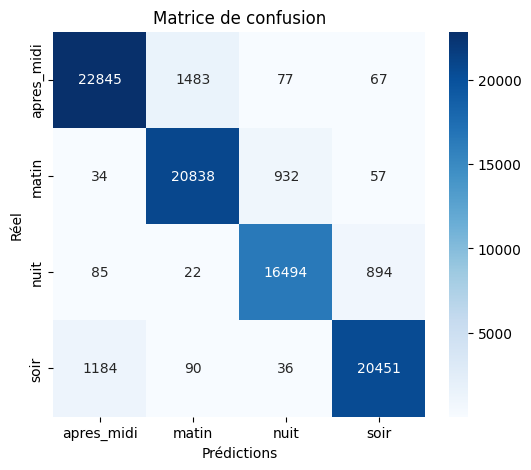

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy déjà calculée
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy sur test : {acc:.2f}")

# Prédictions
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

# Rapport de classification (inclut precision, recall, F1 par classe)
print(classification_report(y_test, y_pred_classes, target_names=encoder.classes_))

# F1-score global (macro et weighted)
print("Macro F1-score :", f1_score(y_test, y_pred_classes, average="macro"))
print("Weighted F1-score :", f1_score(y_test, y_pred_classes, average="weighted"))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.xlabel("Prédictions")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()


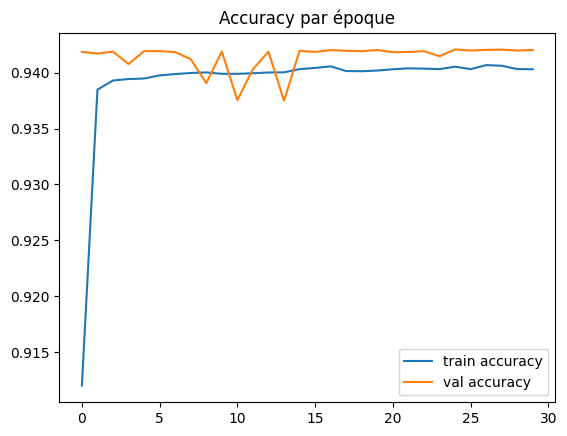

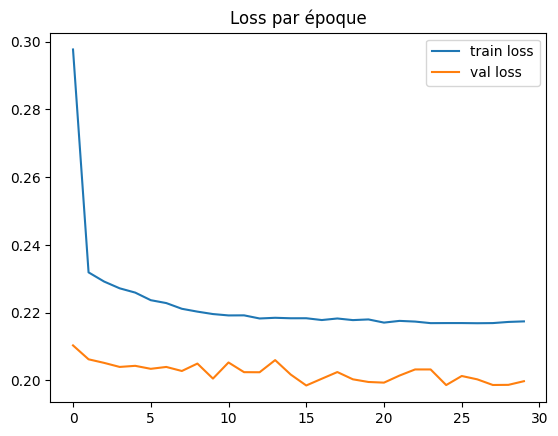

In [ ]:
import matplotlib.pyplot as plt

# Courbe accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy par époque")
plt.show()

# Courbe loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss par époque")
plt.show()


In [ ]:
# Exemple de données
exemple = pd.DataFrame({
    "age": [45],
    "admissionweight": [70],
    "lab_workload_last_hour": [25],
    "result_hour": [10],       # test fait à 10h
    "result_weekday": [2]      # mercredi
})

# Normaliser comme pour l'entraînement
exemple_scaled = scaler.transform(exemple)

# Prédiction
y_pred_exemple = model.predict(exemple_scaled)
classe_predite = encoder.inverse_transform([y_pred_exemple.argmax(axis=1)[0]])
print("Classe prédite pour l'exemple :", classe_predite[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Classe prédite pour l'exemple : matin
